# Customer Lifetime Value (CLV) Modeling

**Goal:** Predict future customer value using probabilistic models (BG/NBD + Gamma-Gamma) to:
- Estimate how many purchases each customer will make in the future
- Predict expected monetary value per transaction
- Calculate 12 month (1 year) CLV for each customer
- Identify highest-value customers for targeted marketing

**Inputs:**
- `online_retail_clean.parquet` (cleaned transaction data)
- `rfm_segments.csv` (customer segments from RFM analysis)

**Outputs:**
- CLV predictions for each customer
- Segment-level CLV analysis
- Actionable business recommendations

**Key Models:**
> **BG/NBD (Beta-Geometric/Negative Binomial Distribution):** Predicts purchase frequency  
> **Gamma-Gamma:** Predicts monetary value per transaction  
> **CLV (revenue-based) = Expected Transactions × Expected Avg Value** (margin unknown)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data

In [2]:
df = pd.read_parquet("../data/online_retail_clean.parquet")

print(f"Shape : {df.shape}")
print(f"Date Range : {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique Customers : {df['Customer ID'].nunique():,}")
df.head()

Shape : (779425, 14)
Date Range : 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique Customers : 5,878


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceWeek,InvoiceStartMonth,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009,12,1,49,2009-12-01,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,49,2009-12-01,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,49,2009-12-01,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009,12,1,49,2009-12-01,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009,12,1,49,2009-12-01,30.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Invoice            779425 non-null  object        
 1   StockCode          779425 non-null  object        
 2   Description        779425 non-null  object        
 3   Quantity           779425 non-null  int64         
 4   InvoiceDate        779425 non-null  datetime64[ns]
 5   Price              779425 non-null  float64       
 6   Customer ID        779425 non-null  int64         
 7   Country            779425 non-null  object        
 8   InvoiceYear        779425 non-null  int32         
 9   InvoiceMonth       779425 non-null  int32         
 10  InvoiceDay         779425 non-null  int32         
 11  InvoiceWeek        779425 non-null  UInt32        
 12  InvoiceStartMonth  779425 non-null  datetime64[ms]
 13  TotalPrice         779425 non-null  float64 

## Prepare Data for Lifetimes

The `lifetimes` library requires a specific format called **RFM summary**:

| Column | Description |
|--------|-------------|
| `frequency` | Number of **repeat** purchases (excludes first purchase) |
| `recency` | Days between first and last purchase |
| `T` | Customer "age" in days (first purchase to analysis date) |
| `monetary_value` | Average order value (for repeat customers only) |

**Important:** A customer with only 1 purchase has frequency=0 and recency=0

In [4]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Analysis Date : {analysis_date}")
summary = summary_data_from_transaction_data(
    df,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalPrice',
    observation_period_end=analysis_date
)
print(f"Summary shape: {summary.shape}")
summary.head(10)

Analysis Date : 2011-12-10 12:50:00
Summary shape: (5878, 4)


,frequency,recency,T,monetary_value
Customer ID,,,,
12346,7.0,400.0,726.0,11066.637143
12347,7.0,402.0,405.0,615.714286
12348,4.0,363.0,439.0,449.310000
12349,3.0,571.0,590.0,1120.056667
12350,0.0,0.0,311.0,0.000000
12351,0.0,0.0,376.0,0.000000
12352,8.0,356.0,393.0,338.261250
12353,1.0,204.0,409.0,89.000000
12354,0.0,0.0,233.0,0.000000


## BG/NBD Model (Purchase Frequency)

**Why BG/NBD?**

Traditional RFM only looks at the past. It can't answer: *"How many purchases will this customer make in the next 6 months?"*

BG/NBD (Beta-Geometric/Negative Binomial Distribution) solves this by modeling two key behaviors:

1. **Purchase Pattern:** How often does each customer buy? (varies per customer)
2. **Dropout Risk:** After each purchase, there's a chance the customer "dies" (churns silently)

**What the model learns:**

| Parameters | What it captures |
|------------|------------------|
| `r`, `alpha` | Purchase frequency distribution across customers |
| `a`, `b` | Churn probability distribution across customers |

**Key outputs for each customer:**
- **P(Alive):** Probability the customer is still active
- **Expected Purchases:** Predicted number of future transactions

In [5]:
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])
bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.665064,0.015853,0.633991,0.696136
alpha,63.273629,1.937269,59.476582,67.070676
a,0.074305,0.007564,0.059480,0.089130
b,1.233373,0.150579,0.938239,1.528507


### Frequency-Recency Analysis

Two key visualizations to understand customer behavior patterns:

1. **Expected Purchases Matrix:** Shows predicted purchase count based on frequency and recency
2. **Probability Alive Matrix:** Shows likelihood that a customer is still active

### Expected Purchases Matrix

Shows the predicted number of purchases in the next 365 days based on customer's historical behavior.

- **X-axis:** Historical purchase frequency (total repeat purchases)
- **Y-axis:** Recency in model terms (days between first and last purchase)
- **Color:** Expected future purchases (yellow = high, purple = low)

**Key insight:** Customers with high frequency and high recency (bottom-right) are the most valuable - they've been consistently purchasing over a long period and will continue to do so.

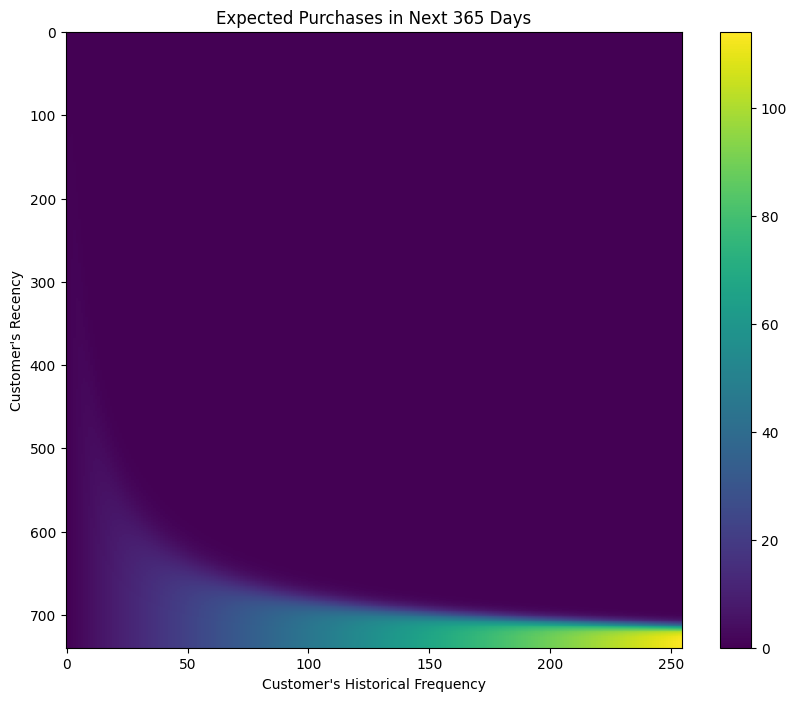

In [6]:
plt.figure(figsize=(10, 8))
plot_frequency_recency_matrix(bgf, T=365)
plt.title('Expected Purchases in Next 365 Days')
plt.show()

### Probability Alive Matrix

Shows the likelihood that a customer is still "alive" (active) and hasn't churned silently.

- **X-axis:** Historical purchase frequency (total repeat purchases)
- **Y-axis:** Recency in model terms (days between first and last purchase)
- **Color:** Probability of being active (yellow = ~100%, purple = ~0%)

**Key insight:** High recency means the customer has been with us for a long period (good sign). Customers with high recency (bottom) have higher P(alive) because they've demonstrated long-term engagement. Low recency (top) means short customer history - uncertain if they'll return.

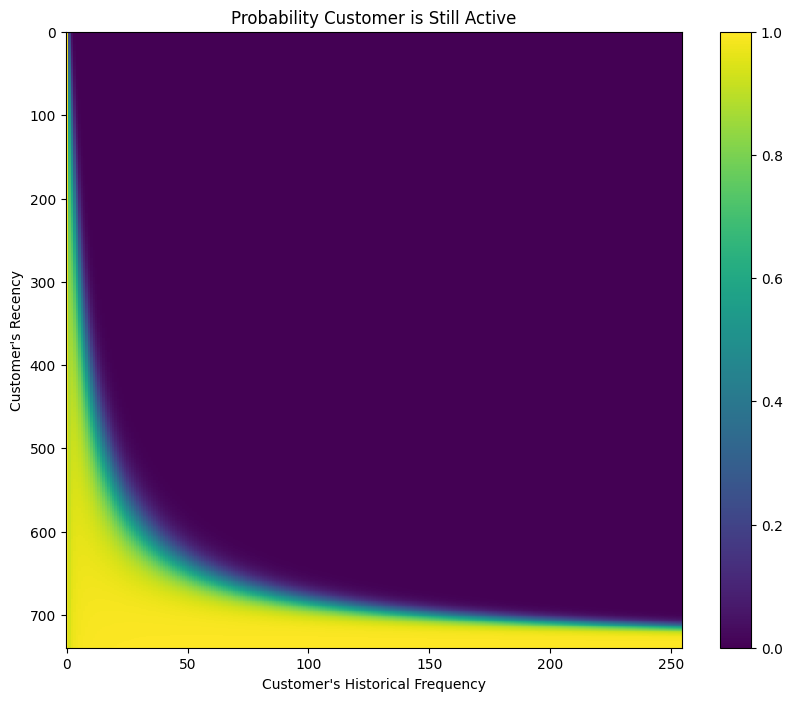

In [7]:
plt.figure(figsize=(10, 8))
plot_probability_alive_matrix(bgf)
plt.title('Probability Customer is Still Active')
plt.show()

## Model Validation (Calibration & Holdout)

We split the observation period into a **calibration** period (model training) and a **holdout** period (unseen data). We fit BG/NBD only on calibration data, then predict purchases in the holdout period and compare to actuals to measure prediction quality.

In [8]:
holdout_days = 180
calibration_end = analysis_date - pd.Timedelta(days = holdout_days)

summary_cal_holdout = calibration_and_holdout_data(
    df,
    customer_id_col="Customer ID",
    datetime_col="InvoiceDate",
    monetary_value_col="TotalPrice",
    observation_period_end=analysis_date,
    calibration_period_end=calibration_end
)

summary_cal_holdout = summary_cal_holdout.reset_index()
summary_cal_holdout.head(10)

,Customer ID,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
0,12346,7.0,400.0,546.0,11066.637143,0.0,0.000000,180.0
1,12347,4.0,221.0,225.0,551.487500,3.0,26.300625,180.0
2,12348,3.0,190.0,259.0,495.746667,1.0,103.333333,180.0
3,12349,2.0,182.0,410.0,801.310000,1.0,24.076027,180.0
4,12350,0.0,0.0,131.0,0.000000,0.0,0.000000,180.0
5,12351,0.0,0.0,196.0,0.000000,0.0,0.000000,180.0
6,12352,5.0,130.0,213.0,352.372000,3.0,20.090000,180.0
7,12353,1.0,204.0,229.0,89.000000,0.0,0.000000,180.0
8,12354,0.0,0.0,53.0,0.000000,0.0,0.000000,180.0
9,12355,1.0,353.0,388.0,459.400000,0.0,0.000000,180.0


In [9]:
bgf_holdout = BetaGeoFitter(penalizer_coef=0.001)
bgf_holdout.fit(
    summary_cal_holdout["frequency_cal"],
    summary_cal_holdout["recency_cal"],
    summary_cal_holdout["T_cal"]
)

duration_holdout = summary_cal_holdout["duration_holdout"].iloc[0]
summary_cal_holdout["predicted_purchases_holdout"] = bgf_holdout.conditional_expected_number_of_purchases_up_to_time(
    duration_holdout,
    summary_cal_holdout["frequency_cal"],
    summary_cal_holdout["recency_cal"],
    summary_cal_holdout["T_cal"]
)

In [10]:
actual = summary_cal_holdout['frequency_holdout']
pred = summary_cal_holdout['predicted_purchases_holdout']

mae = (actual - pred).abs().mean()
rmse = ((actual - pred) ** 2).mean() ** 0.5

pd.DataFrame({
    'metric': ['MAE (purchases)', 'RMSE (purchases)'],
    'value': [round(mae, 4), round(rmse, 4)],
})

,metric,value
0,MAE (purchases),1.0346
1,RMSE (purchases),1.7638


Holdout MAE/RMSE give a sense of prediction error on unseen data. Lower is better. For business use, the main takeaway is that the model is validated on a period it was not trained on.

**Interpretation:** MAE ≈ 1.03 means the model’s predictions are off by about one purchase per customer on average in the 6-month holdout period. For this dataset (where most customers make few transactions), this level of error is reasonable and supports using the model for CLV and segment analysis. The model was not trained on the holdout period, so these metrics indicate how well it generalizes to unseen time.

## Customer-Level Predictions

Using the trained BG/NBD model to predict for each customer:
- **P(Alive):** Probability the customer is still active
- **Expected Purchases:** Predicted number of transactions in next 30, 90, and 365 days

In [11]:
summary["p_alive"] = bgf.conditional_probability_alive(
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

summary["expected_purchase_30"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30,
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

summary["expected_purchases_90"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

summary["expected_purchases_365"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365,
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

summary.head()

,frequency,recency,T,monetary_value,p_alive,expected_purchase_30,expected_purchases_90,expected_purchases_365
Customer ID,,,,,,,,
12346,7.0,400.0,726.0,11066.637143,0.621136,0.180703,0.540594,2.167770
12347,7.0,402.0,405.0,615.714286,0.989324,0.484642,1.447311,5.769375
12348,4.0,363.0,439.0,449.310000,0.963639,0.267883,0.800146,3.191506
12349,3.0,571.0,590.0,1120.056667,0.975033,0.163809,0.489726,1.959163
12350,0.0,0.0,311.0,0.000000,1.000000,0.053113,0.158265,0.626569


## Gamma-Gamma Model (Monetary Value)

BG/NBD tells us *how many* purchases a customer will make. But to calculate CLV, we also need to know *how much* they'll spend per purchase.

**Gamma-Gamma Model** predicts the expected average profit/order for each customer.

**Important:** This model requires `frequency > 0` because:
- We need multiple purchases to estimate average spend
- Single-purchase customers have no spending pattern to model
- They will be handled separately as "New Customers"

In [12]:
summary_with_value = summary[summary["frequency"] > 0].copy()
print(f"Total customers: {len(summary):,}")
print(f"Customers with repeat purchases: {len(summary_with_value):,}")
print(f"Single-purchase customers (excluded): {len(summary) - len(summary_with_value)}")

Total customers: 5,878
Customers with repeat purchases: 4,189
Single-purchase customers (excluded): 1689


### Gamma-Gamma Model Training

**Assumption check:** Gamma-Gamma assumes no correlation between purchase frequency and monetary value. Let's verify this before fitting.

In [13]:
correlation = summary_with_value[["frequency", "monetary_value"]].corr()
print(f"Correlation between frequency and monetary value: {correlation.iloc[0,1]:.3f}")

Correlation between frequency and monetary value: 0.022


In [14]:
ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(summary_with_value["frequency"], summary_with_value["monetary_value"])
ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,11.696137,0.224734,11.255658,12.136615
q,0.888943,0.017071,0.855484,0.922401
v,11.666917,0.229800,11.216509,12.117325


### Gamma-Gamma Assumption Check & Parameter Interpretation

Before fitting the Gamma-Gamma model, we verify a key assumption:

- **Assumption:** Purchase frequency and monetary value are (approximately) independent.
- **Result:** `Correlation between frequency and monetary value: 0.022`  
  → This is very close to 0, so the independence assumption is reasonable for our data.

After fitting the Gamma-Gamma model, we get the following parameters:

| Parameter | Description |
|----------|-------------|
| `p`, `q` | Shape parameters controlling the distribution of customer-level spending (heterogeneity across customers). |
| `v`      | Scale parameter controlling the overall spending level. |

The parameters themselves are not directly interpretable in business terms, but they allow us to compute for each customer:

- **Expected average monetary value per transaction**  
- Which we will then combine with BG/NBD’s **expected number of future purchases** to compute **Customer Lifetime Value (CLV)**.

## Expected Monetary Value per Customer

Using the fitted Gamma-Gamma model to estimate, for each customer:
- **Expected Average Value:** Predicted average revenue per transaction
- Later, this will be combined with BG/NBD expected purchases to compute CLV.

In [15]:
summary_with_value["expected_avg_value"] = ggf.conditional_expected_average_profit(
    summary_with_value["frequency"],
    summary_with_value["monetary_value"]
)

summary_with_value[["frequency", "monetary_value", "expected_avg_value"]].head()

,frequency,monetary_value,expected_avg_value
Customer ID,,,
12346,7.0,11066.637143,11083.337930
12347,7.0,615.714286,618.219577
12348,4.0,449.310000,453.302780
12349,3.0,1120.056667,1127.514300
12352,8.0,338.261250,340.123307


## 1-Year CLV Estimation (Revenue-Based)

Since we don't have reliable gross margin information, we compute **revenue-based CLV**:

\[
CLV_{1y}^{revenue} = \text{Expected Purchases}_{365} \times \text{Expected Avg Value}
\]

This estimates expected customer revenue over the next 12 months.

In [16]:
clv_df = summary_with_value.copy()
clv_df['clv_1y_revenue'] = clv_df['expected_purchases_365'] * clv_df['expected_avg_value']

clv_df[['frequency', 'p_alive', 'expected_purchases_365', 'expected_avg_value', 'clv_1y_revenue']].head()

,frequency,p_alive,expected_purchases_365,expected_avg_value,clv_1y_revenue
Customer ID,,,,,
12346,7.0,0.621136,2.167770,11083.337930,24026.122754
12347,7.0,0.989324,5.769375,618.219577,3566.740418
12348,4.0,0.963639,3.191506,453.302780,1446.718622
12349,3.0,0.975033,1.959163,1127.514300,2208.983830
12352,8.0,0.981566,6.638272,340.123307,2257.830943


## Top Customers by Predicted CLV (Revenue)

We rank customers by predicted 1-year revenue-based CLV and inspect the top customers.

In [17]:
clv_df.sort_values("clv_1y_revenue", ascending = False).head(10)

,frequency,recency,T,monetary_value,p_alive,expected_purchase_30,expected_purchases_90,expected_purchases_365,expected_avg_value,clv_1y_revenue
Customer ID,,,,,,,,,,
16446,1.0,205.0,206.0,168469.600000,0.942845,0.174102,0.518030,2.043350,170096.367170,347566.410866
18102,66.0,738.0,739.0,8768.193939,0.998782,2.486388,7.439357,29.846671,8769.632370,261744.333246
14646,90.0,736.0,738.0,5809.905333,0.998968,3.386360,10.132107,40.650029,5810.648002,236203.010982
17450,30.0,430.0,439.0,6851.561667,0.995739,1.819764,5.436663,21.700445,6854.119940,148737.451255
14096,16.0,97.0,102.0,4071.434375,0.992420,2.982655,8.849216,34.675248,4074.581620,141287.129815
14156,120.0,729.0,739.0,2603.090167,0.997201,4.493298,13.444179,53.939159,2603.393389,140424.848730
14911,254.0,737.0,739.0,1144.437717,0.999448,9.504556,28.438232,114.098155,1144.526435,130588.355040
12415,22.0,503.0,528.0,6460.528636,0.991181,1.137695,3.400883,13.600393,6463.848750,87910.880637
13694,82.0,732.0,736.0,2355.009756,0.998634,3.094236,9.257995,37.142110,2355.424782,87485.446548


## CLV by RFM Segments

We merge CLV predictions with RFM segments to understand which segments drive the most value

In [18]:
rfm = pd.read_csv("../data/rfm_segments.csv")
rfm = rfm.rename(columns={"Customer ID": "customer_id"})

clv_segmented = clv_df.reset_index().rename(columns={"Customer ID": "customer_id"})
clv_segmented = clv_segmented.merge(rfm[["customer_id", "Segment", "is_vip", "is_b2b"]], on = "customer_id", how = "left")

clv_segmented[['customer_id', 'Segment', 'is_vip', 'is_b2b', 'clv_1y_revenue']].head()

,customer_id,Segment,is_vip,is_b2b,clv_1y_revenue
0,12346,VIP,1,0,24026.122754
1,12347,Champions,0,0,3566.740418
2,12348,Loyal,0,0,1446.718622
3,12349,Loyal,0,0,2208.983830
4,12352,Loyal,0,0,2257.830943


## Segment Summary

We report both mean and median CLV, since CLV distributions are typically skewed.

In [19]:
segment_summary = (
    clv_segmented
    .groupby("Segment")["clv_1y_revenue"]
    .agg(customers = "count", mean_clv = "mean", median_clv = "median")
    .sort_values("median_clv", ascending = False)
)

segment_summary

,customers,mean_clv,median_clv
Segment,,,
VIP,58,48763.602179,24517.624305
B2B/Wholesale,2,9527.619488,9527.619488
Champions,550,4128.319890,3278.517819
Loyal,1263,1704.835136,1221.401111
Potential Loyalists,525,1053.646947,603.253195
Others,654,880.284486,573.294282
At Risk,361,633.866015,472.433061
About to Sleep,95,430.215123,279.974492
Lost,681,224.387953,167.252331


## Segment CLV Visualization

We visualize CLV by segment using **median** (robust to outliers) and inspect the distribution on a log scale.

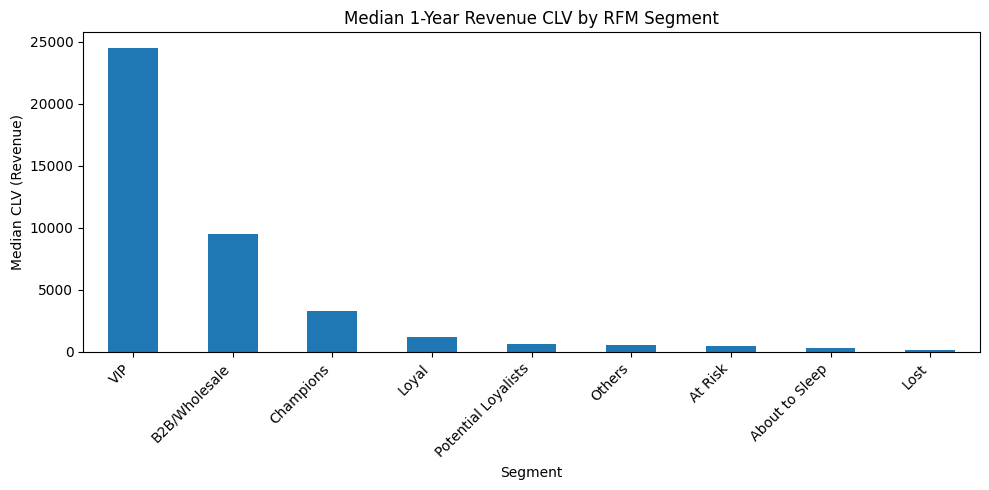

In [20]:
plt.figure(figsize=(10, 5))
segment_summary['median_clv'].sort_values(ascending=False).plot(kind='bar')
plt.title('Median 1-Year Revenue CLV by RFM Segment')
plt.ylabel('Median CLV (Revenue)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### CLV Distribution

CLV is typically right-skewed, so we inspect the distribution and also view it on a log scale.

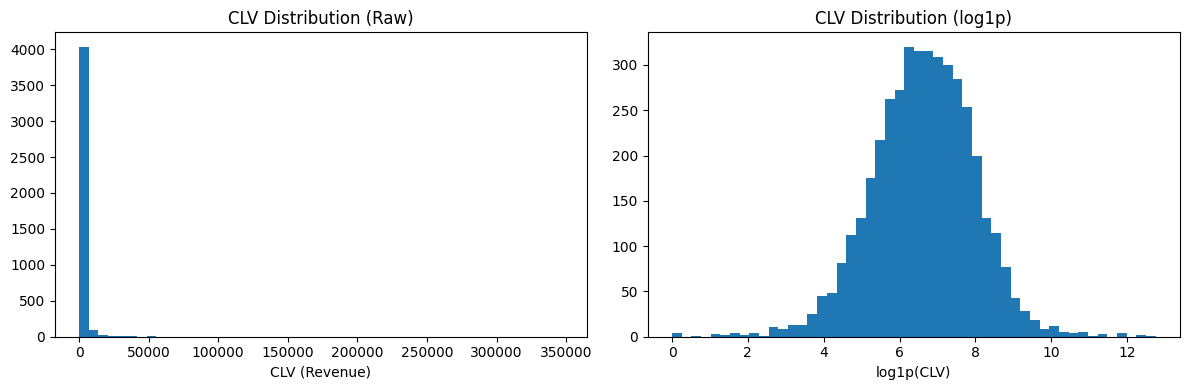

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(clv_segmented['clv_1y_revenue'], bins=50)
axes[0].set_title('CLV Distribution (Raw)')
axes[0].set_xlabel('CLV (Revenue)')

axes[1].hist(np.log1p(clv_segmented['clv_1y_revenue']), bins=50)
axes[1].set_title('CLV Distribution (log1p)')
axes[1].set_xlabel('log1p(CLV)')

plt.tight_layout()
plt.show()

### CLV by VIP / B2B Flags

We compare CLV distributions across VIP and B2B customers to see whether a small group dominates overall value.

In [22]:
clv_segmented.assign(
    vip_flag=clv_segmented['is_vip'].map({0: 'Non-VIP', 1: 'VIP'}),
    b2b_flag=clv_segmented['is_b2b'].map({0: 'Non-B2B', 1: 'B2B'})
).groupby(['vip_flag', 'b2b_flag'])['clv_1y_revenue'].agg(
    customers='count',
    mean_clv='mean',
    median_clv='median'
).sort_values('median_clv', ascending=False)

customers      mean_clv    median_clv
vip_flag b2b_flag                                       
VIP      B2B              19  86519.400721  50958.296140
         Non-B2B          39  30369.751607  17754.454898
Non-VIP  B2B               2   9527.619488   9527.619488
         Non-B2B        4129   1447.119807    758.729059

## Top Customers (Explainability View)

To understand extreme CLV values, we inspect the top customers and the components behind CLV:
- expected purchases (BG/NBD)
- expected average value (Gamma-Gamma)
- predicted CLV (revenue)

In [23]:
top_n = 20

top_customers = (
    clv_segmented
    .sort_values('clv_1y_revenue', ascending=False)
    [['customer_id', 'Segment', 'is_vip', 'is_b2b',
      'p_alive', 'expected_purchases_365', 'expected_avg_value', 'clv_1y_revenue']]
    .head(top_n)
)

top_customers

,customer_id,Segment,is_vip,is_b2b,p_alive,expected_purchases_365,expected_avg_value,clv_1y_revenue
2904,16446,VIP,1,1,0.942845,2.043350,170096.367170,347566.410866
4074,18102,VIP,1,1,0.998782,29.846671,8769.632370,261744.333246
1638,14646,VIP,1,1,0.998968,40.650029,5810.648002,236203.010982
3628,17450,VIP,1,0,0.995739,21.700445,6854.119940,148737.451255
1234,14096,VIP,1,0,0.992420,34.675248,4074.581620,141287.129815
1277,14156,VIP,1,1,0.997201,53.939159,2603.393389,140424.848730
1821,14911,VIP,1,1,0.999448,114.098155,1144.526435,130588.355040
50,12415,VIP,1,0,0.991181,13.600393,6463.848750,87910.880637
939,13694,VIP,1,1,0.998634,37.142110,2355.424782,87485.446548
3673,17511,VIP,1,0,0.998214,22.697831,3381.360073,76749.540003


## Coverage: Who Gets a CLV Prediction?

Gamma-Gamma requires **repeat purchases** (`frequency > 0`), so CLV is computed only for customers with repeat transactions.

We report:
- total customers in the dataset
- customers with repeat purchases (CLV computed)
- single-purchase customers (treated as "New Customers")

## Export for Dashboard

Save CLV and segment summary so the Streamlit app can load them without re-running the model.

In [24]:
total_customers = summary.shape[0]
repeat_customers = (summary['frequency'] > 0).sum()
new_customers = (summary['frequency'] == 0).sum()

pd.DataFrame({
    'group': ['Total customers', 'Repeat customers (CLV computed)', 'New customers (single purchase)'],
    'customers': [total_customers, repeat_customers, new_customers],
    'share': [1.0, repeat_customers / total_customers, new_customers / total_customers]
})

,group,customers,share
0,Total customers,5878,1.000000
1,Repeat customers (CLV computed),4189,0.712657
2,New customers (single purchase),1689,0.287343


## Outlier / Concentration Check

CLV is typically right-skewed. We quantify concentration by measuring how much of total predicted CLV is driven by the top 1% customers.

In [25]:
clv_sorted = clv_segmented.sort_values('clv_1y_revenue', ascending=False).copy()

top_1pct_n = max(1, int(np.ceil(0.01 * len(clv_sorted))))
top_1pct_share = clv_sorted.head(top_1pct_n)['clv_1y_revenue'].sum() / clv_sorted['clv_1y_revenue'].sum()

pd.DataFrame({
    'metric': ['customers_with_clv', 'top_1pct_customers', 'top_1pct_share_of_total_clv'],
    'value': [len(clv_sorted), top_1pct_n, top_1pct_share]
})

,metric,value
0,customers_with_clv,4189.000000
1,top_1pct_customers,42.000000
2,top_1pct_share_of_total_clv,0.305676


## Segment Value Contribution (Sum vs Median)

Median CLV describes the typical customer value. Total CLV (sum) shows which segments contribute most to overall predicted revenue.

In [26]:
segment_value = (
    clv_segmented
    .groupby('Segment')['clv_1y_revenue']
    .agg(customers='count', total_clv='sum', mean_clv='mean', median_clv='median')
    .sort_values('total_clv', ascending=False)
)

segment_value

,customers,total_clv,mean_clv,median_clv
Segment,,,,
VIP,58,2.828289e+06,48763.602179,24517.624305
Champions,550,2.270576e+06,4128.319890,3278.517819
Loyal,1263,2.153207e+06,1704.835136,1221.401111
Others,654,5.757061e+05,880.284486,573.294282
Potential Loyalists,525,5.531646e+05,1053.646947,603.253195
At Risk,361,2.288256e+05,633.866015,472.433061
Lost,681,1.528082e+05,224.387953,167.252331
About to Sleep,95,4.087044e+04,430.215123,279.974492
B2B/Wholesale,2,1.905524e+04,9527.619488,9527.619488


## Segment Size vs Median CLV

Median CLV is robust, but segment sizes vary a lot (e.g., B2B groups can be very small).
We plot segment size alongside median CLV for better interpretation.

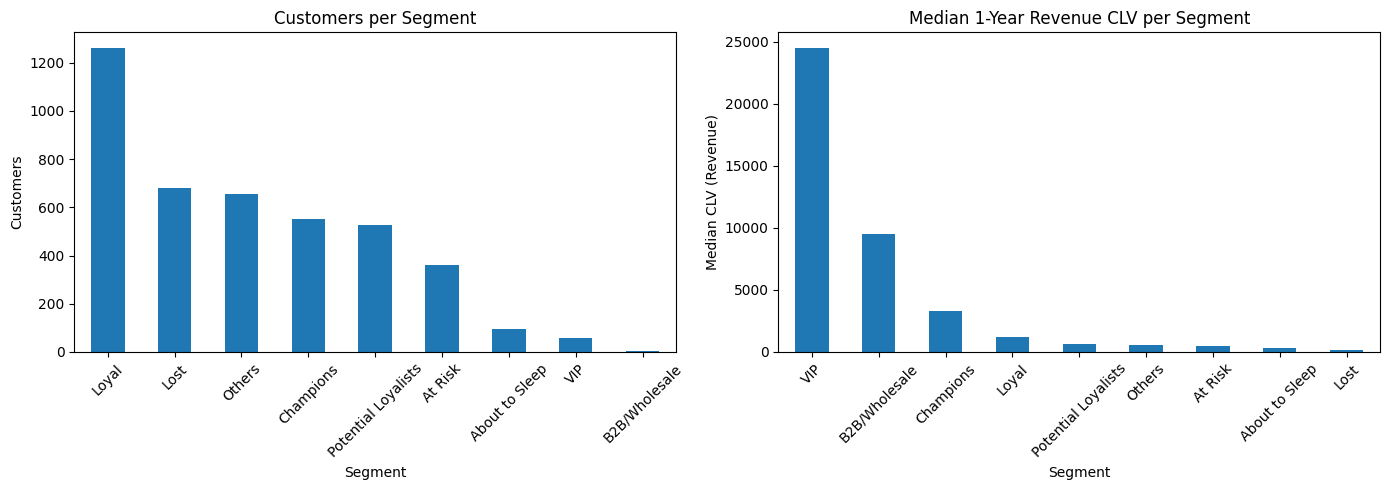

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment size
segment_summary['customers'].sort_values(ascending=False).plot(kind='bar', ax=axes[0])
axes[0].set_title('Customers per Segment')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=45)

# Median CLV
segment_summary['median_clv'].sort_values(ascending=False).plot(kind='bar', ax=axes[1])
axes[1].set_title('Median 1-Year Revenue CLV per Segment')
axes[1].set_ylabel('Median CLV (Revenue)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Key Takeaways Before Insights

- Predicted value is highly concentrated: the **top 1% customers generate ~31%** of total predicted CLV.
- Segment contribution differs by metric:
  - **VIP** has the highest median CLV and the largest total CLV.
  - **Champions** and **Loyal** also contribute heavily in total due to segment size.

## Business Insights & Actions (Based on Predicted Revenue CLV)

### 1) CLV is highly concentrated (Pareto-like)
A small fraction of customers drives a large share of predicted revenue CLV (see the top 1% concentration check).
**Action:** Treat high-CLV customers as a protected asset: prioritize retention, service quality, and proactive outreach.

### 2) Segment strategy should depend on both “typical CLV” and “total contribution”
- **Median CLV** tells us the *typical* customer value in a segment (robust to outliers).
- **Total CLV (sum)** tells us where the *overall revenue impact* is (segment size matters).

**Action:** Allocate budget using both:
- Retention budget → segments with high median CLV (e.g., VIP / Champions).
- Growth budget → segments with large total CLV (often larger segments like Loyal/Champions).

### 3) Recommended actions by segment (examples)
- **VIP / Champions:** retention-first (exclusive offers, early access, concierge support, churn-prevention triggers).
- **Loyal:** increase basket size and frequency (bundles, cross-sell, replenishment reminders).
- **Potential Loyalists:** accelerate habit formation (welcome-back offers, personalized recommendations).
- **At Risk / About to Sleep:** win-back campaigns (time-limited incentives, product reminders).
- **Lost:** low-cost reactivation only (broad campaigns; avoid expensive incentives).
- **B2B/Wholesale:** even if median CLV is high, segment size can be tiny; focus on account-based actions if operationally feasible.

### 4) Use CLV + P(alive) for prioritization
High predicted CLV with low P(alive) can be a good “save” target.
High predicted CLV with high P(alive) is a “protect and grow” target.

## Model Limitations & Assumptions

- **Revenue-based CLV:** We predict expected *revenue* (not profit) because margin is unknown/unstable. Profit-based CLV would require reliable margin by product/customer.
- **Repeat-only monetary model:** Gamma-Gamma requires repeat purchases, so single-purchase customers are excluded from monetary estimation and reported separately in Coverage.
- **BG/NBD assumptions:** Purchase process and dropout are simplified; behavior shifts (seasonality, promotions, supply shocks) are not explicitly modeled.
- **Data quality:** Returns/cancellations, pricing anomalies, and extreme orders can distort monetary estimates; CLV distributions are right-skewed and sensitive to outliers.
- **No causal interpretation:** High predicted CLV correlates with past behavior; it does not prove that an intervention caused the value.
- **Time horizon:** Results are specific to the chosen horizon (e.g., 12 months) and the observation period. Different horizons can change rankings.